# M1–M6：三種資料的原始區間與 Local-scale 比較

本 notebook 包含 M1M9-GARCH、0050 與太陽黑子三種實驗。M1–M5 保留各自原始區間，再套用相同的 Local-scale conformal calibration；M6 使用 Local-scale residual shortest interval 一次，不重複校準。執行後會在 notebook 內顯示每組 summary 與預測圖。

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src').exists()),None)
if ROOT is None: raise RuntimeError('找不到 project/meeting')
sys.path.insert(0,str(ROOT/'src'))
from kf_forecasting.models.kf_enbpi import EnbPIConfig,shortest_residual_offsets,simulate_m1_m9_garch_low_constant_high_variance_data
from kf_forecasting.models.kf_out_of_time_enbpi import OutOfTimeEnbPIConfig,run_out_of_time_enbpi,select_residual_window
from kf_forecasting.models.six_method_benchmark import METHOD_NAMES,interval_metrics,load_sister_definitions,run_sister_methods
ALPHA=.05; K=60; SEED=2026

## Local-scale 演算法（直接定義於 notebook）

In [2]:
def state_features(y,times,points):
    y=np.asarray(y,float); rows=[]
    for t,p in zip(np.asarray(times,int),np.asarray(points,float)):
        h=y[:t]; d12=np.diff(h[-13:]); d36=np.diff(h[-37:])
        rows.append([p,p-h[-1],np.std(d12,ddof=1) if len(d12)>1 else 0.,np.std(d36,ddof=1) if len(d36)>1 else 0.])
    return np.asarray(rows,float)

def local_scale(train_x,abs_error,query_x,k=K,leave_self=False):
    scaler=RobustScaler().fit(train_x); x=scaler.transform(train_x); q=scaler.transform(query_x)
    distance=((q[:,None,:]-x[None,:,:])**2).sum(2)
    if leave_self and len(query_x)==len(train_x): np.fill_diagonal(distance,np.inf)
    n=min(k,len(train_x)-int(leave_self)); idx=np.argpartition(distance,n-1,axis=1)[:,:n]
    scale=np.median(np.asarray(abs_error)[idx],axis=1)
    return np.maximum(scale,max(float(np.quantile(abs_error,.10)),1e-6))

def conformal_q(values,alpha=ALPHA):
    values=np.asarray(values,float); prob=min(1.,np.ceil((len(values)+1)*(1-alpha))/len(values))
    return float(np.quantile(values,prob,method='higher'))

def calibrate_raw_interval(y,cal,test):
    cal=cal.sort_values('time').reset_index(drop=True); test=test.sort_values('time').reset_index(drop=True)
    x=state_features(y,cal.time,cal.point); error=cal.truth.to_numpy()-cal.point.to_numpy(); scales=np.empty(len(cal))
    for i in range(len(cal)):
        keep=np.arange(len(cal))!=i; scales[i]=local_scale(x[keep],abs(error[keep]),x[i:i+1],leave_self=False)[0]
    scores=np.maximum(cal.lower-cal.truth,cal.truth-cal.upper).to_numpy()/scales
    pool=scores.copy(); max_pool=len(pool); dynamic_x=x.copy(); dynamic_abs=abs(error).copy(); rows=[]
    for r in test.itertuples(index=False):
        xt=state_features(y,[r.time],[r.point]); sigma=local_scale(dynamic_x,dynamic_abs,xt)[0]; q=conformal_q(pool)
        lower=r.lower-sigma*q; upper=r.upper+sigma*q
        if lower>upper: lower=upper=(r.lower+r.upper)/2
        rows.append({'time':r.time,'method':r.method,'truth':r.truth,'point':r.point,'lower':lower,'upper':upper})
        err=r.truth-r.point; raw_score=max(r.lower-r.truth,r.truth-r.upper)
        dynamic_x=np.vstack([dynamic_x,xt]); dynamic_abs=np.r_[dynamic_abs,abs(err)]; pool=np.r_[pool,raw_score/sigma][-max_pool:]
    return pd.DataFrame(rows)

def run_m6_original_and_local(y,train_size):
    fit=run_out_of_time_enbpi(y,train_size,config=OutOfTimeEnbPIConfig(base=EnbPIConfig(alpha=ALPHA,random_state=SEED)),model_name=METHOD_NAMES[5],data_seed=SEED)
    f=fit.forecast; c=fit.crossfit_predictions; times=c.time.to_numpy(int); residual=c.final_residual.to_numpy(float); x=state_features(y,times,c.final_point)
    scales=local_scale(x,abs(residual),x,leave_self=True); z=residual/scales
    cfg=OutOfTimeEnbPIConfig(base=f.config,residual_window_candidates=(24,60,120,180,300,None)); window,_=select_residual_window(z,cfg)
    pool=z.copy() if window is None else z[-window:].copy(); max_pool=len(pool); raw_point=f.point-f.bias_correction; tx=state_features(y,f.test_times,raw_point)
    dynamic_x=x.copy(); dynamic_abs=abs(residual).copy(); rows=[]
    for t,truth,raw,xt in zip(f.test_times,f.truth,raw_point,tx):
        sigma=local_scale(dynamic_x,dynamic_abs,xt[None,:])[0]; bias=np.mean(pool) if f.config.oob_bias_correction else 0.; lo,hi,_=shortest_residual_offsets(pool-bias,ALPHA,f.config.beta_grid_size)
        point=raw+sigma*bias; rows.append({'time':t,'method':METHOD_NAMES[5],'truth':truth,'point':point,'lower':point+sigma*lo,'upper':point+sigma*hi})
        err=truth-raw; pool=np.r_[pool,err/sigma][-max_pool:]; dynamic_x=np.vstack([dynamic_x,xt]); dynamic_abs=np.r_[dynamic_abs,abs(err)]
    original=pd.DataFrame({'time':f.test_times,'method':METHOD_NAMES[5],'truth':f.truth,'point':f.point,'lower':f.lower,'upper':f.upper})
    return original,pd.DataFrame(rows)


In [3]:
def run_comparison(y, train_size, dates, inverse=lambda x: x, show_plot=True):
    cal_start = int(0.8 * train_size)
    ns, cal_frames, raw_frames = load_sister_definitions(), [], []

    with TemporaryDirectory() as tmp:
        sister_cal = run_sister_methods(
            y[:train_size], cal_start, seed=SEED, ns=ns,
            checkpoint_dir=Path(tmp)/'calibration'
        )
        sister_full = run_sister_methods(
            y, train_size, seed=SEED, ns=ns,
            checkpoint_dir=Path(tmp)/'full_training'
        )

    for method, (point, lower, upper, _) in sister_cal.items():
        cal_frames.append(pd.DataFrame({
            "time": np.arange(cal_start, train_size),
            "method": method,
            "truth": y[cal_start:train_size],
            "point": point,
            "lower": lower,
            "upper": upper,
        }))
    for method, (point, lower, upper, _) in sister_full.items():
        raw_frames.append(pd.DataFrame({
            'time': np.arange(train_size,len(y)), 'method': method,
            'truth': y[train_size:], 'point': point,
            'lower': lower, 'upper': upper,
        }))

    calibration = pd.concat(cal_frames, ignore_index=True)
    m6_original,m6_local=run_m6_original_and_local(y,train_size)
    raw=pd.concat([*raw_frames,m6_original],ignore_index=True)

    local = [
        calibrate_raw_interval(
            y,
            calibration[calibration.method.eq(method)],
            raw[raw.method.eq(method)],
        )
        for method in METHOD_NAMES[:5]
    ]
    local.append(m6_local)
    local = pd.concat(local, ignore_index=True)

    frames, rows = [], []

    for version, data in [("Original", raw), ("Local-scale", local)]:
        for method in METHOD_NAMES:
            d = data[data.method.eq(method)].sort_values("time")
            truth, point, lower, upper = [
                np.asarray(inverse(d[c].to_numpy(float)))
                for c in ["truth", "point", "lower", "upper"]
            ]

            rows.append({
                "method": method,
                "version": version,
                **interval_metrics(
                    truth, point, lower, upper, alpha=ALPHA
                ),
            })

            frames.append(pd.DataFrame({
                "date": dates,
                "method": method,
                "version": version,
                "truth": truth,
                "point": point,
                "lower": lower,
                "upper": upper,
            }))

    predictions = pd.concat(frames, ignore_index=True)
    summary = pd.DataFrame(rows).drop(columns=['mse','mae'],errors='ignore')

    if show_plot:
        fig, axes = plt.subplots(6, 2, figsize=(18, 25), sharex=True)

        for i, method in enumerate(METHOD_NAMES):
            for j, version in enumerate(["Original", "Local-scale"]):
                d = predictions[
                    predictions.method.eq(method)
                    & predictions.version.eq(version)
                ]
                ax = axes[i, j]
                ax.plot(d.date, d.truth, "k", lw=1, label="Truth")
                ax.plot(d.date, d.point, color="tab:blue", lw=0.9, label="Point")
                ax.fill_between(
                    d.date, d.lower, d.upper,
                    color="tab:blue", alpha=0.2
                )
                ax.set_title(f"{method} — {version}")
                ax.grid(alpha=0.2)

        axes[0, 0].legend(ncol=2)
        fig.tight_layout()
        plt.show()

    return summary, predictions

# 實驗一：M1M9-GARCH（20次配對蒙地卡羅）

使用 seeds 2020–2039。每個 seed 的原始與 Local-scale 方法使用完全相同的模擬路徑；最後報告20次平均值與標準差。

In [4]:
TRAIN=650; H=200; MC_SEEDS=range(2020,2040)
mc_summaries=[]; mc_predictions=[]
for mc_seed in MC_SEEDS:
    SEED=mc_seed  # Local-scale、模型與資料均使用同一配對seed
    _,_,y=simulate_m1_m9_garch_low_constant_high_variance_data(TRAIN+H,rng=np.random.default_rng(mc_seed))
    one_summary,one_predictions=run_comparison(y,TRAIN,pd.Index(np.arange(TRAIN,TRAIN+H)),show_plot=False)
    one_summary.insert(0,'seed',mc_seed); one_predictions.insert(0,'seed',mc_seed)
    mc_summaries.append(one_summary); mc_predictions.append(one_predictions)
    print(f'finished seed {mc_seed}')
SEED=2026
m1m9_metrics_by_seed=pd.concat(mc_summaries,ignore_index=True)
m1m9_predictions=pd.concat(mc_predictions,ignore_index=True)
display(m1m9_metrics_by_seed.round(3))

c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\states

finished seed 2020


c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarnin

finished seed 2021


c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model

...

c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model

finished seed 2038


c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model

finished seed 2039


,seed,method,version,rmse,coverage,coverage_percent,mean_width,median_width,mean_interval_score,lower_miss_rate,upper_miss_rate
0,2020,M1_DistPred_ANN,Original,2.914,0.925,92.5,10.193,9.342,15.366,0.050,0.025
1,2020,M2_DistPred_Minusformer,Original,3.200,0.915,91.5,11.589,10.475,16.285,0.050,0.035
2,2020,M3_Quantile_ANN,Original,2.958,0.920,92.0,11.122,10.004,15.747,0.050,0.030
3,2020,M4_Quantile_Minusformer,Original,3.203,0.770,77.0,7.738,7.373,23.001,0.130,0.100
4,2020,M5_SortBootstrap_ANN,Original,2.921,0.670,67.0,5.481,5.166,25.726,0.170,0.160
...,...,...,...,...,...,...,...,...,...,...,...
235,2039,M2_DistPred_Minusformer,Local-scale,3.880,0.945,94.5,16.120,15.046,18.650,0.030,0.025
236,2039,M3_Quantile_ANN,Local-scale,3.679,0.975,97.5,17.793,15.842,18.736,0.010,0.015
237,2039,M4_Quantile_Minusformer,Local-scale,3.552,0.955,95.5,16.083,15.424,18.091,0.025,0.020
238,2039,M5_SortBootstrap_ANN,Local-scale,3.436,0.950,95.0,14.516,13.769,16.848,0.025,0.025


In [5]:
metric_cols=['rmse','coverage_percent','mean_width','median_width','mean_interval_score','lower_miss_rate','upper_miss_rate']
m1m9_summary=(m1m9_metrics_by_seed.groupby(['method','version'])[metric_cols].agg(['mean','std']).round(3))
m1m9_summary

rmse        coverage_percent          \
                                      mean    std             mean     std   
method                  version                                              
M1_DistPred_ANN         Local-scale  3.366  0.617           96.300   1.069   
                        Original     3.366  0.617           90.350   2.611   
M2_DistPred_Minusformer Local-scale  3.500  0.659           95.625   1.459   
                        Original     3.500  0.659           89.350   2.616   
M3_Quantile_ANN         Local-scale  3.366  0.602           96.100   1.501   
                        Original     3.366  0.602           91.675   2.336   
M4_Quantile_Minusformer Local-scale  3.564  0.710           95.775   1.957   
                        Original     3.564  0.710           66.225  17.251   
M5_SortBootstrap_ANN    Local-scale  3.193  0.578           95.675   1.206   
                        Original     3.193  0.578           64.850   3.554   
M6_OOT_Adaptive_EnbPI   Local-scale  3.327  0.585           92.300   1.881   
                        Original     3.327  0.586           92.200   3.439   

                                    mean_width        median_width         \
                                          mean    std         mean    std   
method                  version                                             
M1_DistPred_ANN         Local-scale     14.931  2.870       14.366  2.660   
                        Original        11.769  2.120       11.250  1.992   
M2_DistPred_Minusformer Local-scale     15.809  2.776       15.028  2.437   
                        Original        12.091  1.827       11.337  1.674   
M3_Quantile_ANN         Local-scale     15.110  2.856       14.325  2.538   
                        Original        12.327  2.016       11.753  1.820   
M4_Quantile_Minusformer Local-scale     16.329  3.735       15.651  3.359   
                        Original         7.987  4.126        7.336  3.797   
M5_SortBootstrap_ANN    Local-scale     13.640  2.400       12.988  2.133   
                        Original         5.783  0.621        5.602  0.566   
M6_OOT_Adaptive_EnbPI   Local-scale     12.433  1.832       12.034  1.795   
                        Original        12.352  1.417       12.184  1.399   

                                    mean_interval_score          \
                                                   mean     std   
method                  version                                   
M1_DistPred_ANN         Local-scale              17.064   3.519   
                        Original                 17.625   4.023   
M2_DistPred_Minusformer Local-scale              17.923   3.637   
                        Original                 18.987   4.476   
M3_Quantile_ANN         Local-scale              17.266   3.554   
                        Original                 17.313   3.971   
M4_Quantile_Minusformer Local-scale              18.728   3.925   
                        Original                 35.410  14.293   
M5_SortBootstrap_ANN    Local-scale              15.968   3.099   
                        Original                 30.793   8.163   
M6_OOT_Adaptive_EnbPI   Local-scale              16.824   3.222   
                        Original                 17.585   4.115   

                                    lower_miss_rate        upper_miss_rate  \
                                               mean    std            mean   
method                  version                                              
M1_DistPred_ANN         Local-scale           0.020  0.010           0.017   
                        Original              0.048  0.015           0.048   
M2_DistPred_Minusformer Local-scale           0.021  0.009           0.023   
                        Original              0.056  0.013           0.050   
M3_Quantile_ANN         Local-scale           0.016  0.011           0.023   
                        Original              0.036  0.016           0.047   
M4_

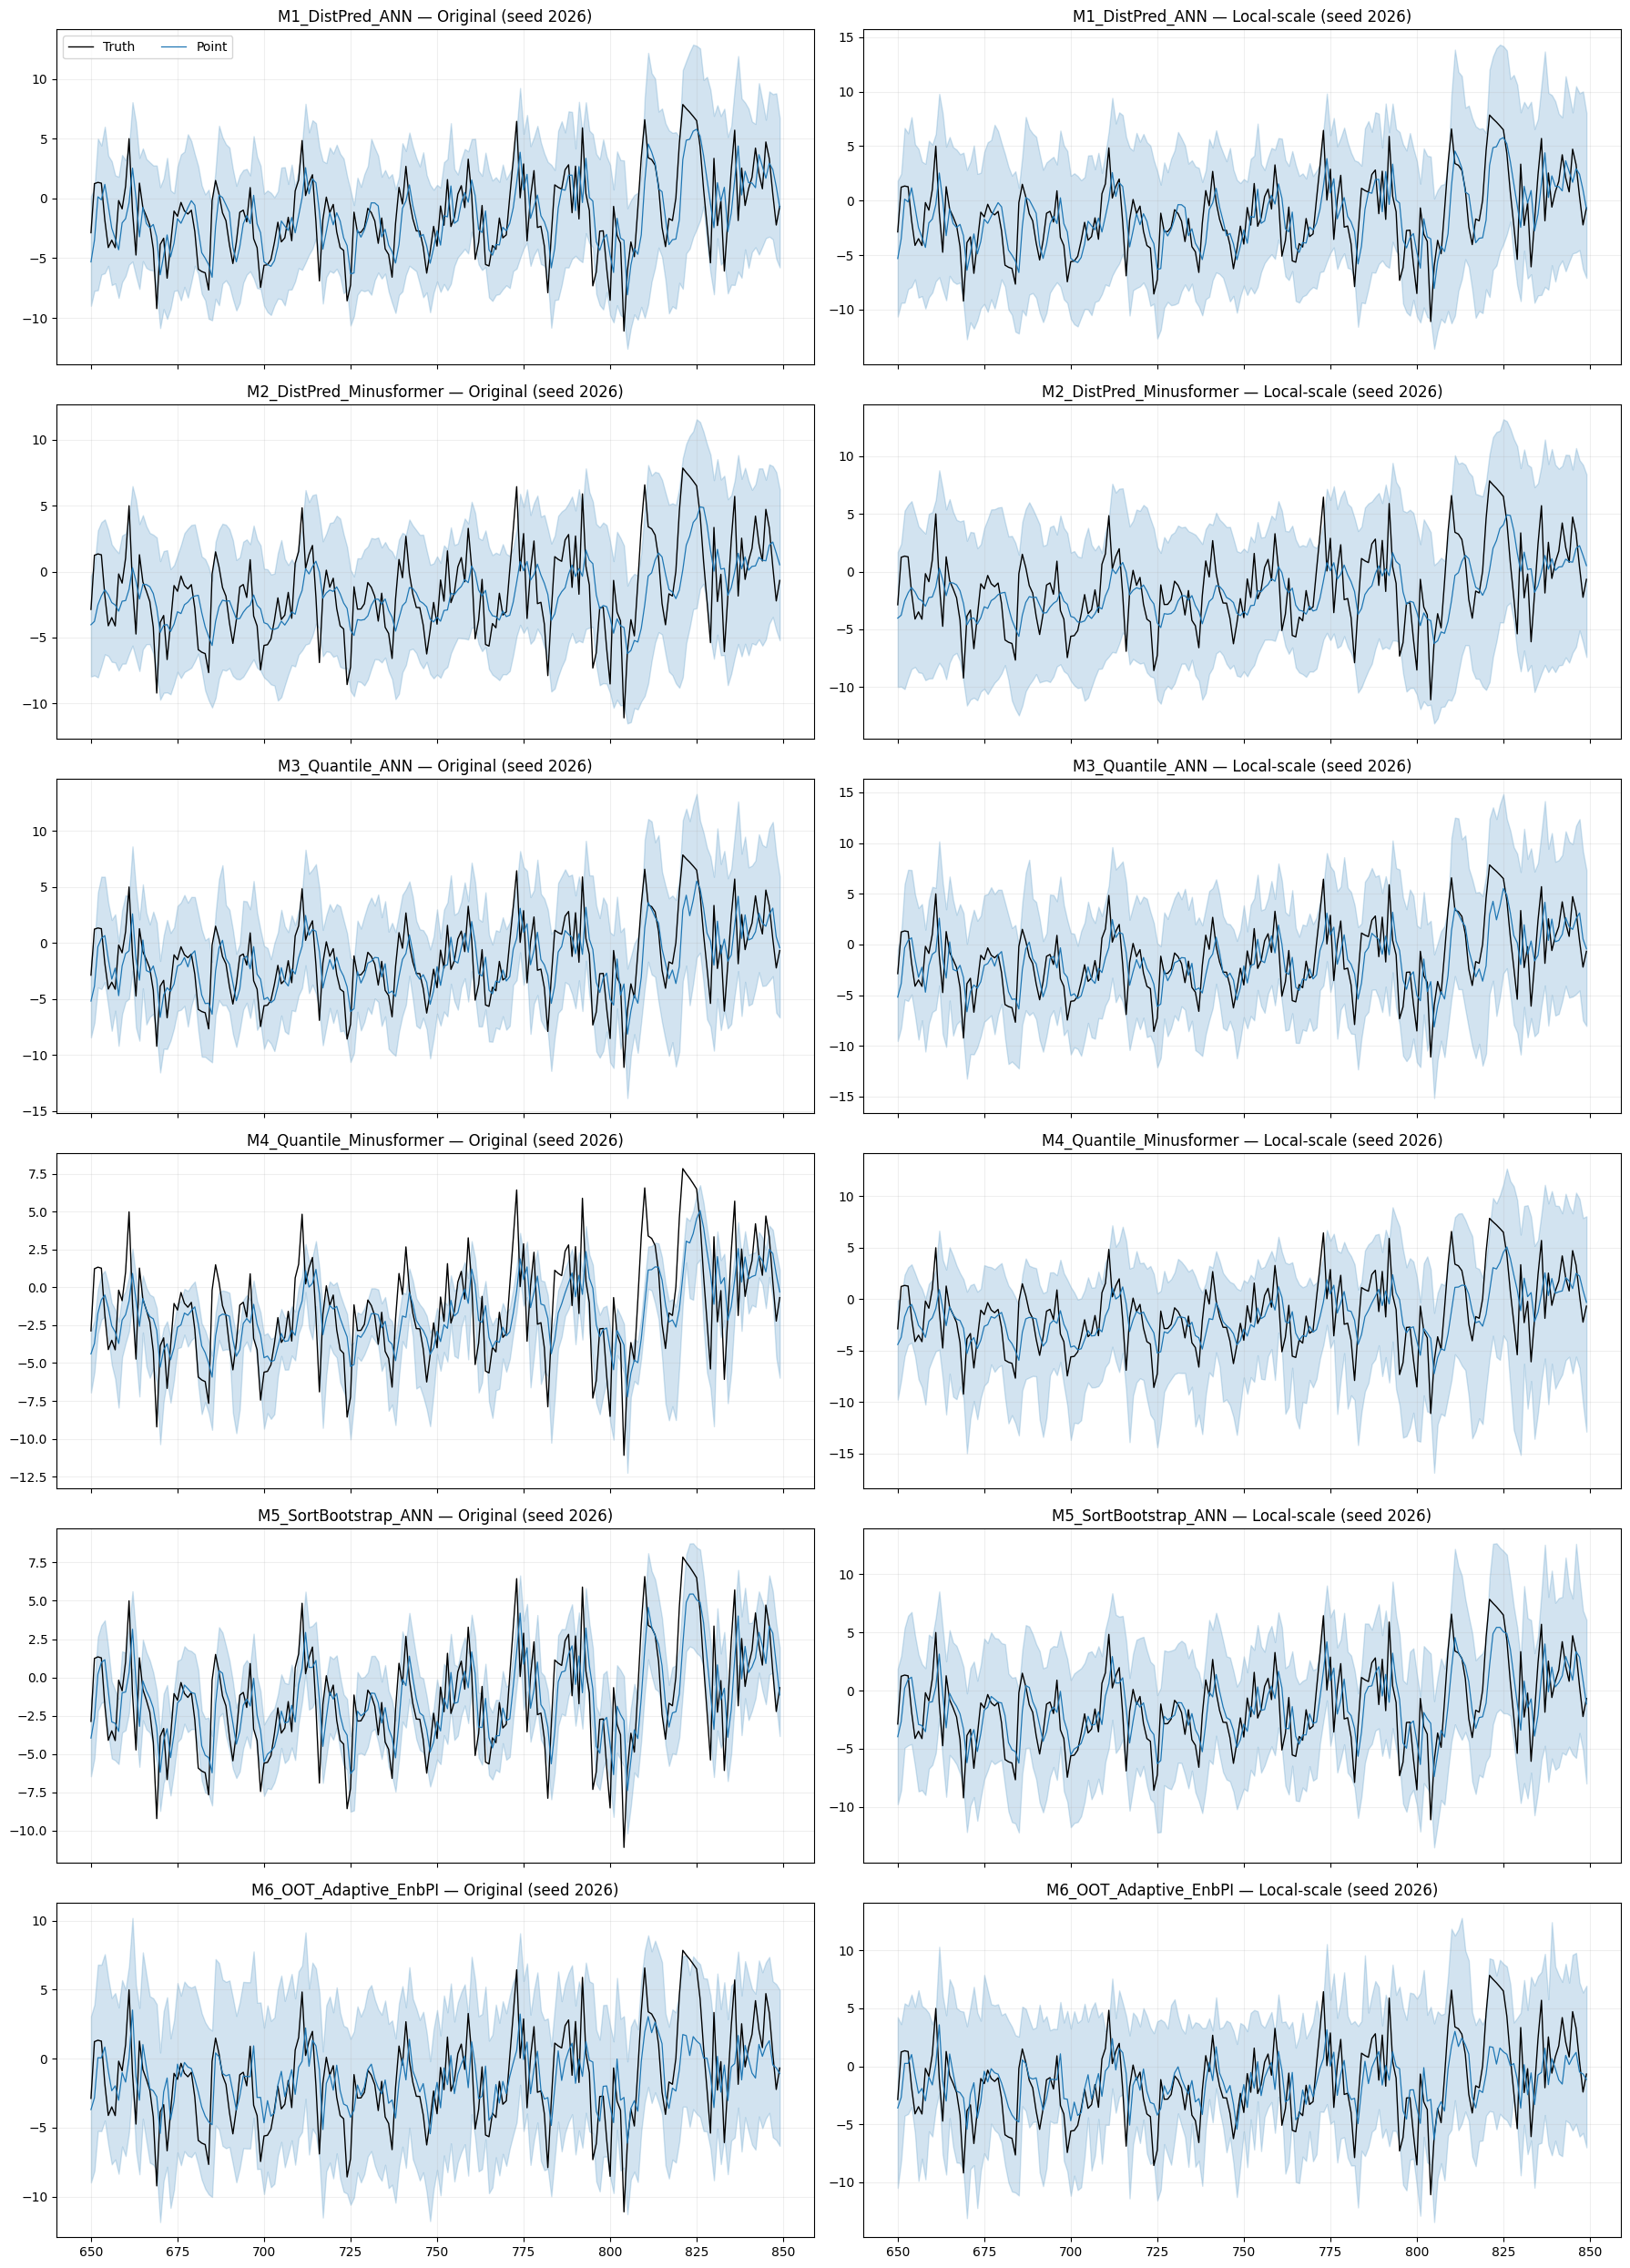

In [6]:
# 代表性預測圖：seed 2026；正式數值結論以上方20次蒙地卡羅summary為準
representative=m1m9_predictions[m1m9_predictions.seed.eq(2026)]
fig,axes=plt.subplots(6,2,figsize=(18,25),sharex=True)
for i,m in enumerate(METHOD_NAMES):
    for j,v in enumerate(['Original','Local-scale']):
        d=representative[(representative.method==m)&(representative.version==v)]; ax=axes[i,j]
        ax.plot(d.date,d.truth,'k',lw=1,label='Truth'); ax.plot(d.date,d.point,color='tab:blue',lw=.9,label='Point'); ax.fill_between(d.date,d.lower,d.upper,color='tab:blue',alpha=.2); ax.set_title(f'{m} — {v} (seed 2026)'); ax.grid(alpha=.2)
axes[0,0].legend(ncol=2); fig.tight_layout(); plt.show()

# 實驗二：0050

c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserW

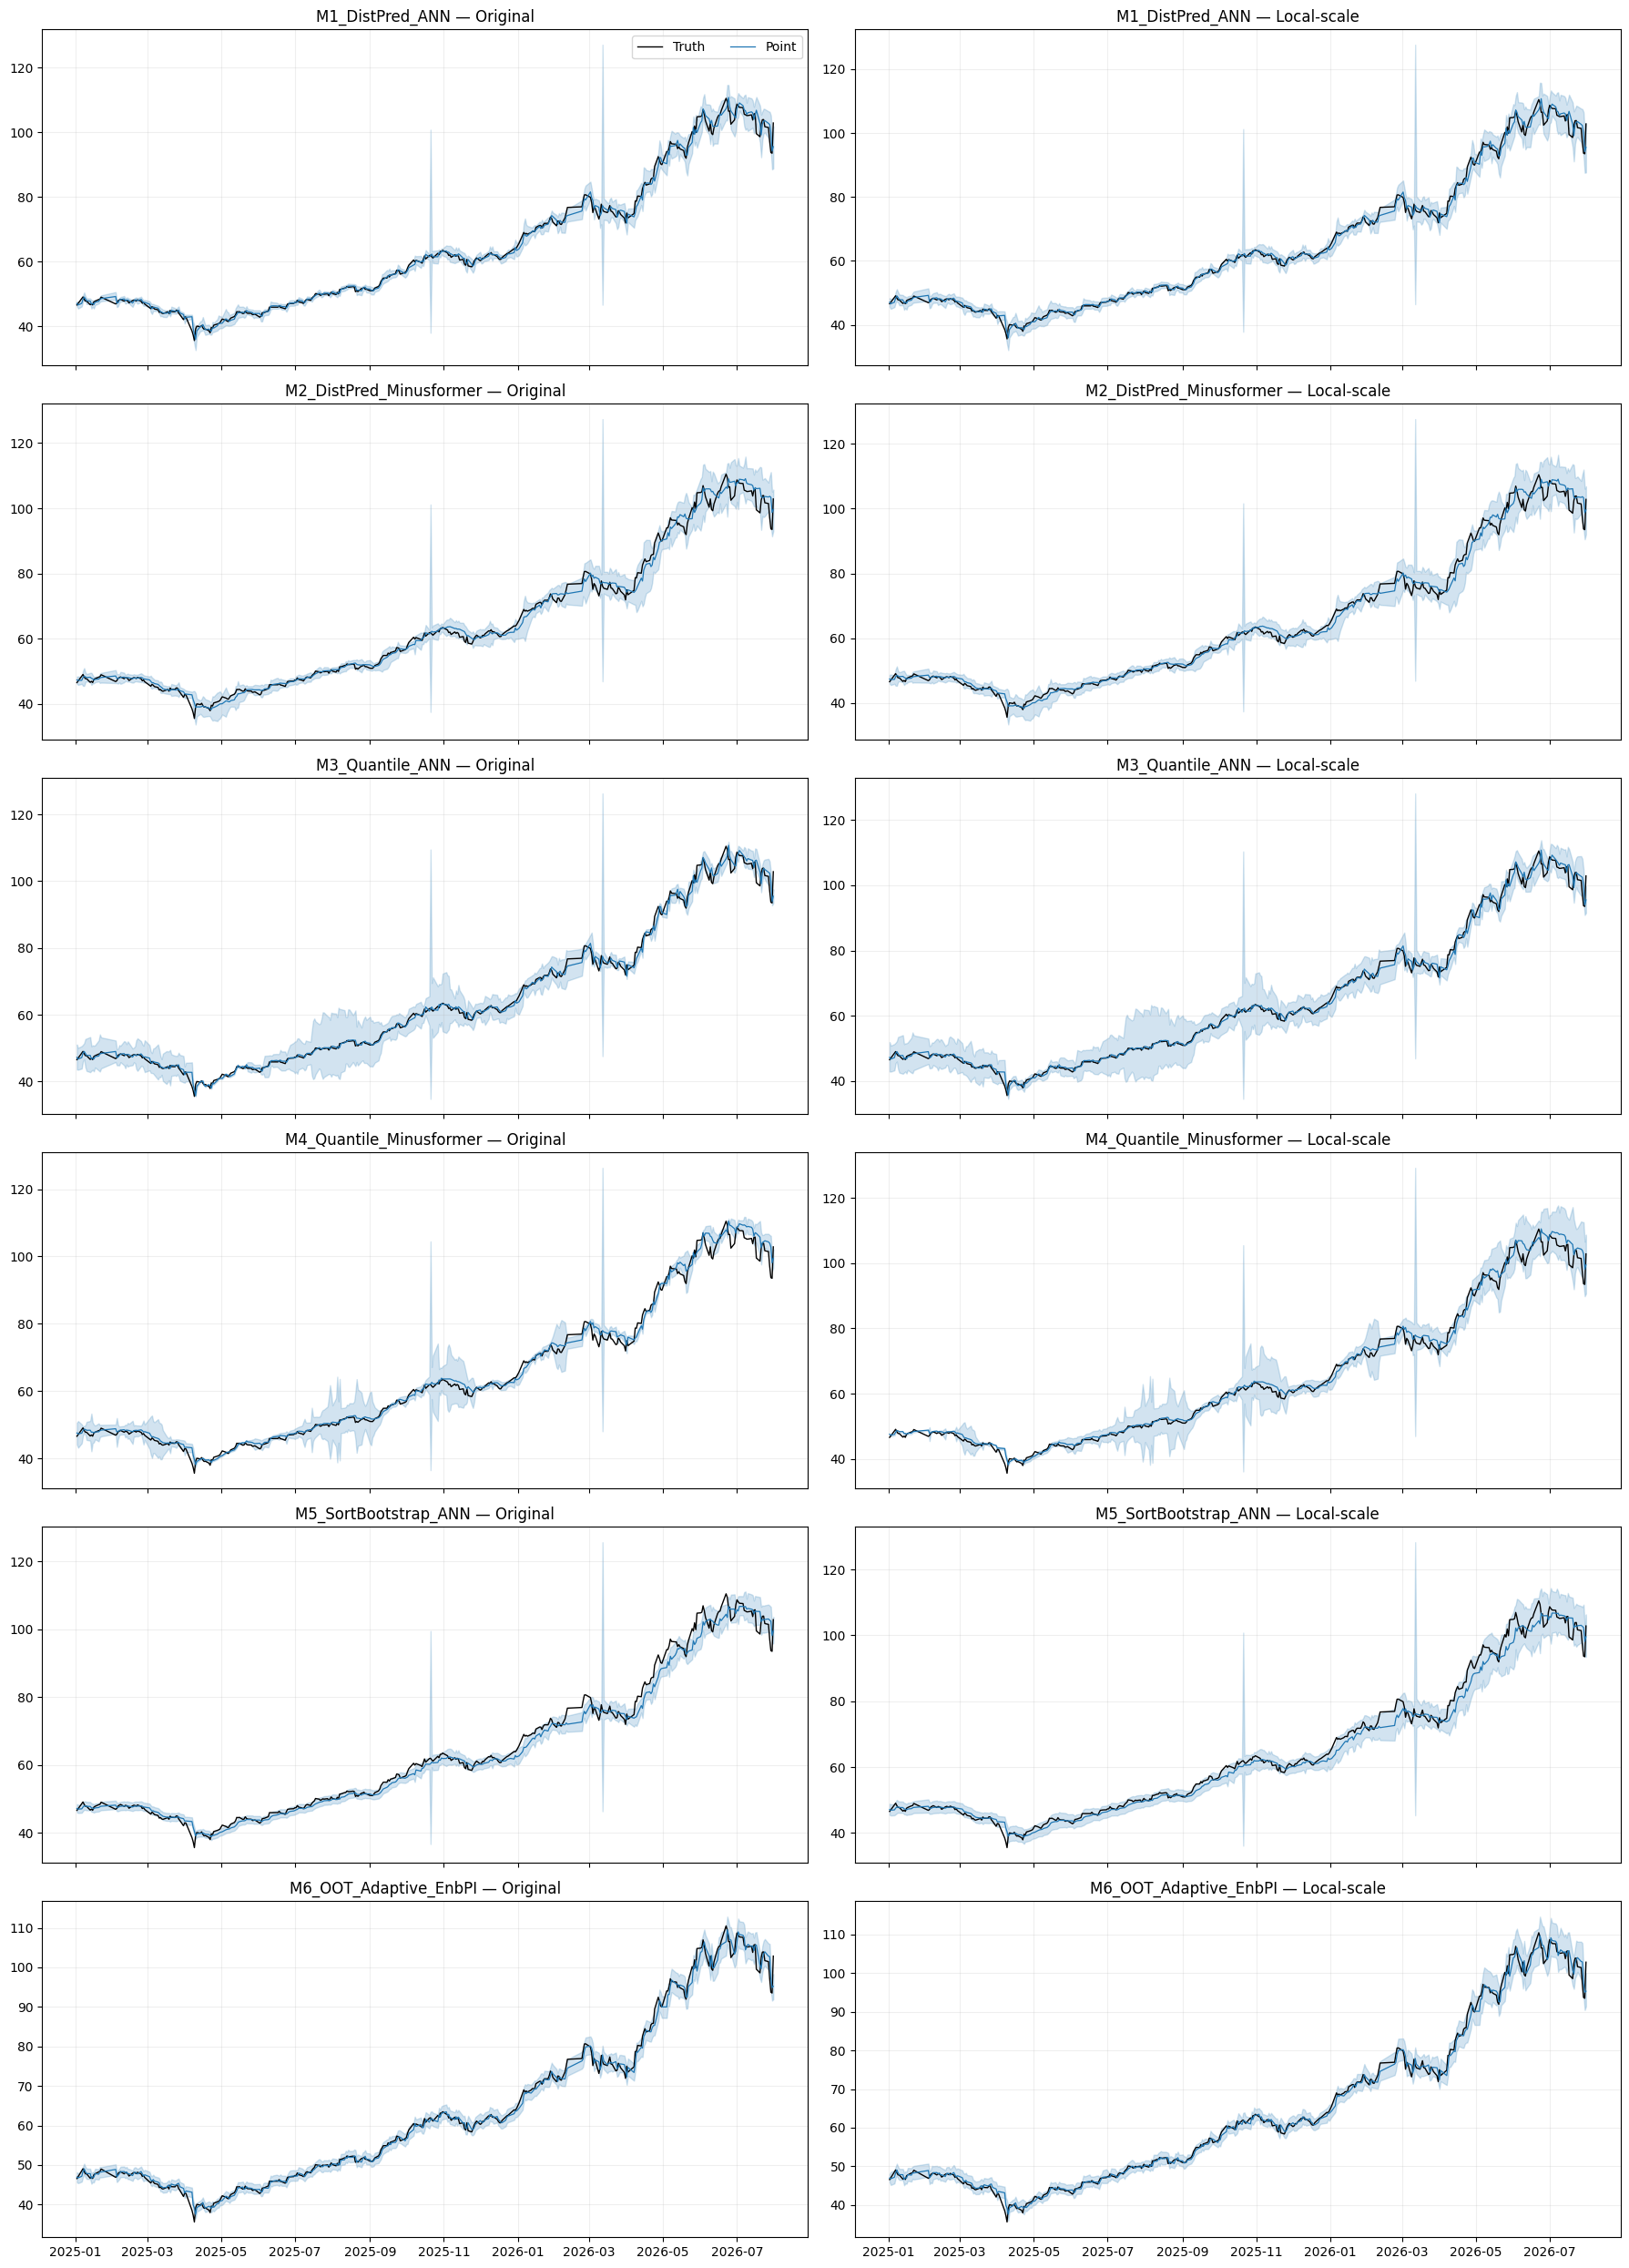

,method,version,rmse,coverage,coverage_percent,mean_width,median_width,mean_interval_score,lower_miss_rate,upper_miss_rate
0,M1_DistPred_ANN,Original,1.409,0.906,90.576,4.351,2.952,7.080,0.052,0.042
1,M2_DistPred_Minusformer,Original,1.879,0.921,92.147,6.090,4.512,8.140,0.060,0.018
2,M3_Quantile_ANN,Original,1.413,0.825,82.461,6.881,5.851,14.531,0.094,0.081
3,M4_Quantile_Minusformer,Original,1.822,0.688,68.848,5.130,3.153,19.714,0.178,0.134
4,M5_SortBootstrap_ANN,Original,2.155,0.754,75.393,4.183,3.110,16.004,0.055,0.191
5,M6_OOT_Adaptive_EnbPI,Original,1.337,0.911,91.099,3.711,3.298,7.360,0.047,0.042
6,M1_DistPred_ANN,Local-scale,1.409,0.950,95.026,5.397,3.865,6.755,0.029,0.021
7,M2_DistPred_Minusformer,Local-scale,1.879,0.953,95.288,6.703,4.932,8.093,0.037,0.010
8,M3_Quantile_ANN,Local-scale,1.413,0.942,94.241,8.896,7.753,11.085,0.026,0.031
9,M4_Quantile_Minusformer,Local-scale,1.822,0.838,83.770,7.466,5.648,12.101,0.089,0.073


In [7]:
close=pd.read_csv(ROOT/'data/raw/0050_adjusted_close.csv',parse_dates=['Date']).set_index('Date').adjusted_close
train=close.loc['2020':'2024']; test=close.loc['2025-01-01':'2026-07-31']; y=np.log(pd.concat([train,test]).to_numpy(float))
tw0050_summary,tw0050_predictions=run_comparison(y,len(train),test.index,np.exp)
display(tw0050_summary.round(3))

# 實驗三：太陽黑子

c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model

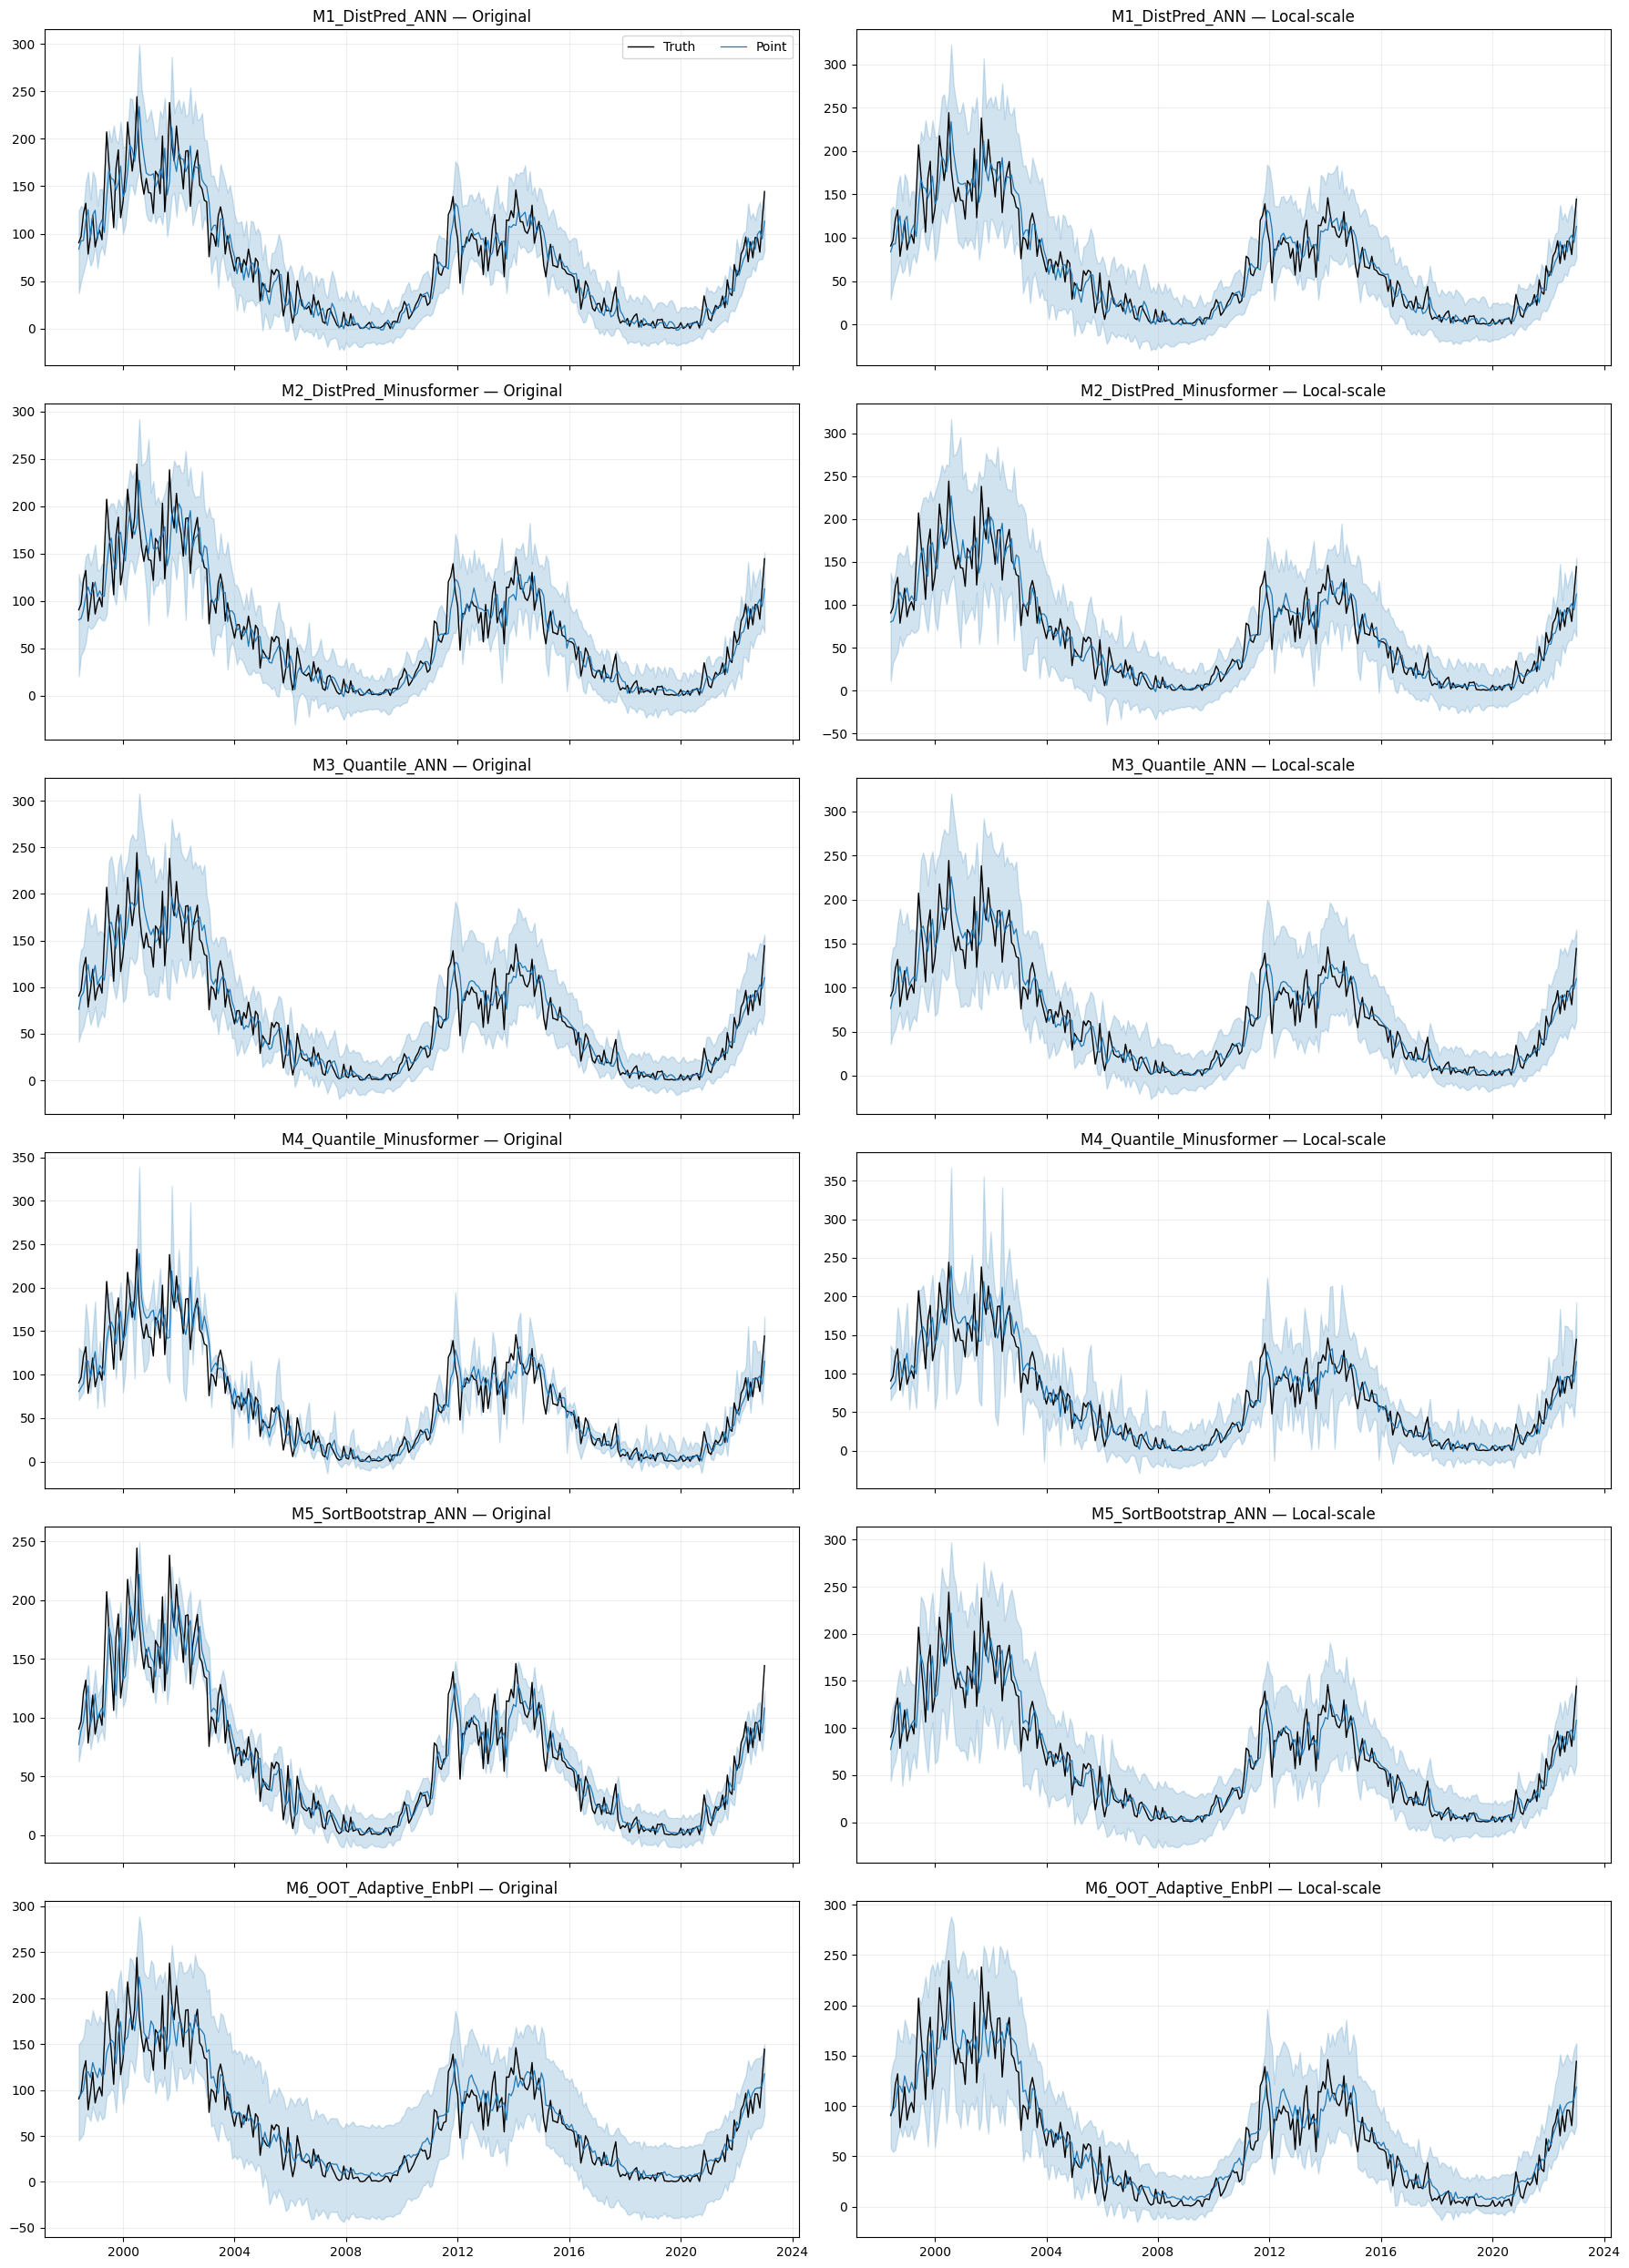

,method,version,rmse,coverage,coverage_percent,mean_width,median_width,mean_interval_score,lower_miss_rate,upper_miss_rate
0,M1_DistPred_ANN,Original,19.887,0.902,90.203,63.794,60.566,107.028,0.054,0.044
1,M2_DistPred_Minusformer,Original,19.938,0.922,92.230,64.908,58.242,103.185,0.030,0.047
2,M3_Quantile_ANN,Original,19.886,0.926,92.568,68.512,58.151,94.361,0.034,0.041
3,M4_Quantile_Minusformer,Original,20.364,0.635,63.514,33.093,28.070,258.780,0.199,0.166
4,M5_SortBootstrap_ANN,Original,19.596,0.696,69.595,33.614,32.134,177.780,0.152,0.152
5,M6_OOT_Adaptive_EnbPI,Original,19.581,0.973,97.297,97.859,99.481,107.378,0.017,0.010
6,M1_DistPred_ANN,Local-scale,19.887,0.956,95.608,82.248,77.841,99.175,0.017,0.027
7,M2_DistPred_Minusformer,Local-scale,19.938,0.966,96.622,84.674,75.375,100.674,0.014,0.020
8,M3_Quantile_ANN,Local-scale,19.886,0.956,95.608,82.303,70.384,92.167,0.017,0.027
9,M4_Quantile_Minusformer,Local-scale,20.364,0.929,92.905,74.448,63.328,120.638,0.044,0.027


In [8]:
cols=['year','month','decimal_date','sunspot','std','observations','provisional']; d=pd.read_csv(ROOT/'data/raw/SN_m_tot_V2.0.csv',sep=';',header=None,names=cols); d['date']=pd.to_datetime(dict(year=d.year,month=d.month,day=1))
series=d.loc[d.date.between('1900-01-01','2023-01-01')&d.sunspot.ge(0)].set_index('date').sunspot.astype(float).sort_index(); n=int(.8*len(series)); test=series.iloc[n:]
sunspot_summary,sunspot_predictions=run_comparison(series.to_numpy(),n,test.index)
display(sunspot_summary.round(3))